# # Model 2 — Candidate Ranking: Dataset Exploration & Training
# This notebook covers:
# 1. Dataset overview and quality checks
# 2. Education field analysis (university, diploma, speciality)
# 3. Score distribution
# 4. Feature extraction & model training
# 5. SHAP explainability

In [7]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
 
sns.set_theme(style="whitegrid")
DATA_PATH = Path("../data/dataset_clean.csv")

In [8]:
# ## 1. Load & overview

In [9]:
DATA_PATH = Path("../data/dataset_clean.csv")
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head(3)

Shape: (9348, 11)


,university_clean,degree_norm,speciality_norm,degree_list,speciality_list,candidate_skills,required_skills,job_position_name,education_required,experience_years_required,matched_score
0,The Amity School of Engineering & Technology (...,Bachelor,Electronics,['B.Tech'],['Electronics'],"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",[],Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,1.0,0.850000
1,Delhi University - Hansraj College,Master,Mathematics,"['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['Mathematics', 'Statistics']","['Data Analysis', 'Data Analytics', 'Business ...",[],Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,5.0,0.750000
2,"Birla Institute of Technology (BIT), Ranchi",Bachelor,Electronics,['B.Tech'],['Electronics/Telecommunication'],"['Software Development', 'Machine Learning', '...","['Brand Promotion', 'Campaign Management', 'Fi...","Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),3.0,0.416667


In [10]:
print("Null counts:")
print(df.isnull().sum())

Null counts:
university_clean               28
degree_norm                   906
speciality_norm              2176
degree_list                     0
speciality_list                 0
candidate_skills                0
required_skills                 0
job_position_name               0
education_required              0
experience_years_required    1336
matched_score                   0
dtype: int64


# ## 2. Priority field coverage: University, Diploma, Speciality

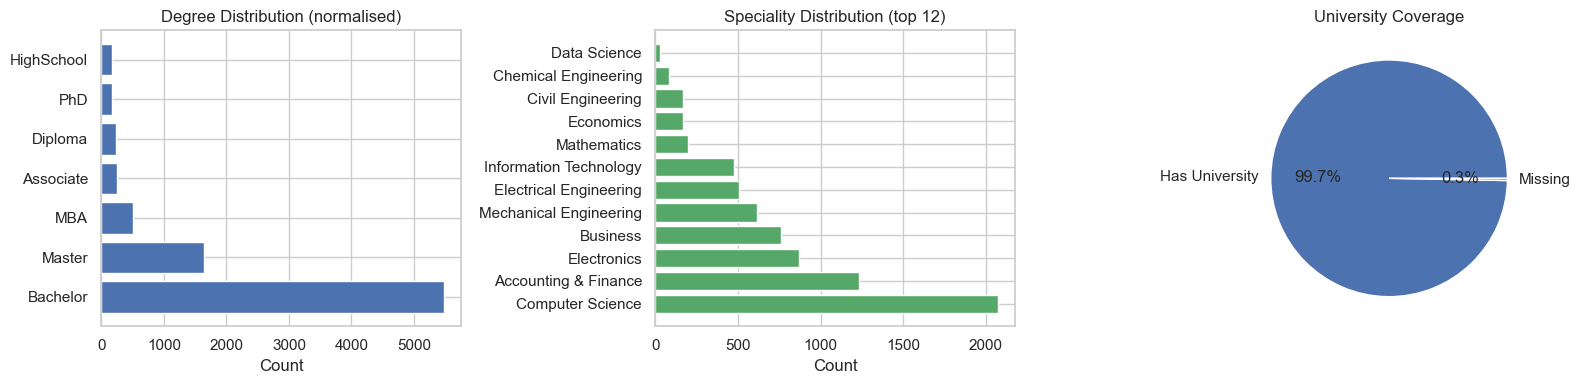

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
# Degree distribution
degree_counts = df["degree_norm"].value_counts()
axes[0].barh(degree_counts.index, degree_counts.values, color="#4C72B0")
axes[0].set_title("Degree Distribution (normalised)")
axes[0].set_xlabel("Count")
# Speciality distribution (top 12)
spec_counts = df["speciality_norm"].value_counts().head(12)
axes[1].barh(spec_counts.index, spec_counts.values, color="#55A868")
axes[1].set_title("Speciality Distribution (top 12)")
axes[1].set_xlabel("Count")
 
# University presence
univ_coverage = df["university_clean"].notna().value_counts()
axes[2].pie(
    univ_coverage.values,
    labels=["Has University", "Missing"],
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"]
)
axes[2].set_title("University Coverage")
 
plt.tight_layout()
# ensure target directory exists before saving
MODEL_PLOTS_DIR = Path("../models/plots")
MODEL_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(MODEL_PLOTS_DIR / "education_overview.png", dpi=150)
plt.show()

# ## 3. Matched score distribution

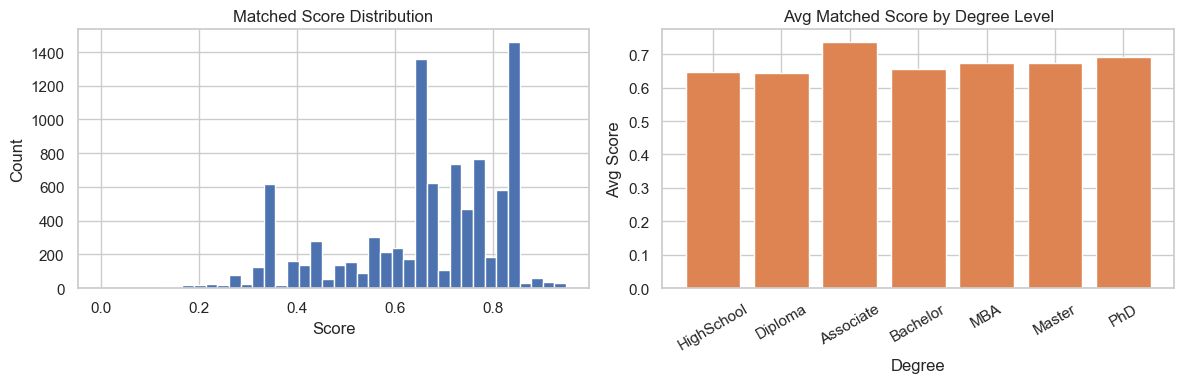

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].hist(df["matched_score"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Matched Score Distribution")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Count")
 
# Score by degree level
degree_order = ["HighSchool", "Diploma", "Associate", "Bachelor", "MBA", "Master", "PhD"]
degree_scores = df[df["degree_norm"].notna()].groupby("degree_norm")["matched_score"].mean()
degree_scores = degree_scores.reindex([d for d in degree_order if d in degree_scores.index])
axes[1].bar(degree_scores.index, degree_scores.values, color="#DD8452")
axes[1].set_title("Avg Matched Score by Degree Level")
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("Avg Score")
axes[1].tick_params(axis="x", rotation=30)
 
plt.tight_layout()
plt.savefig("../models/plots/score_analysis.png", dpi=150)
plt.show()

# ## 4. Feature extraction & model training

In [14]:
import sys
sys.path.append("../training")
sys.path.append("../app")
 
from feature_extractor import FeatureExtractor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
 
extractor = FeatureExtractor()
 
# This will take a few minutes on ~9k rows
print("Extracting features (this takes a few minutes)...")
X = extractor.extract_batch(df)
y = df["matched_score"].values
 
print(f"\nFeature matrix shape: {X.shape}")
X.describe()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting features (this takes a few minutes)...
  Extracting features: 9348/9348 ✓

Feature matrix shape: (9348, 7)


,skill_score,speciality_score,degree_score,has_university,n_candidate_skills,n_required_skills,skill_gap_ratio
count,9348.000000,9348.000000,9348.000000,9348.0,9348.000000,9348.000000,9348.000000
mean,0.054427,0.242553,0.790704,1.0,0.400877,0.072142,0.945573
std,0.149343,0.149841,0.360652,0.0,0.282501,0.054577,0.149343
min,0.000000,0.000000,0.000000,1.0,0.060000,0.000000,0.000000
25%,0.000000,0.129100,0.500000,1.0,0.200000,0.040000,1.000000
50%,0.000000,0.218100,1.000000,1.0,0.280000,0.060000,1.000000
75%,0.000000,0.317700,1.000000,1.0,0.580000,0.120000,1.000000
max,1.000000,0.919300,1.000000,1.0,1.000000,0.180000,1.000000


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
model = GradientBoostingRegressor(
    n_estimators=200, max_depth=4,
    learning_rate=0.05, subsample=0.8,
    random_state=42
)
model.fit(X_train, y_train)
 
preds = model.predict(X_test)
print(f"Test MAE : {mean_absolute_error(y_test, preds):.4f}")
print(f"Test R²  : {r2_score(y_test, preds):.4f}")

Test MAE : 0.1006
Test R²  : 0.3855


# ## 5. Feature Importances

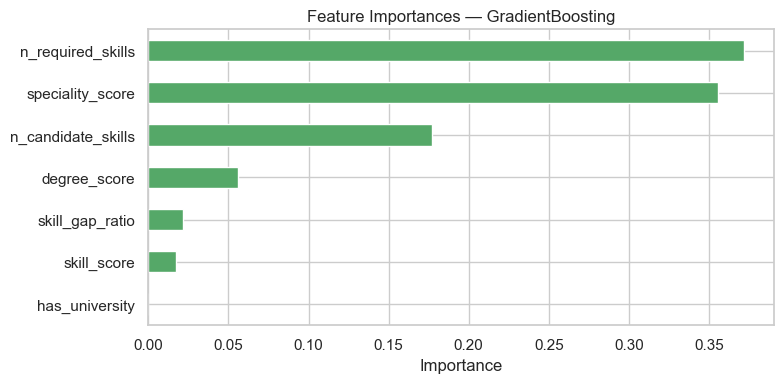

In [17]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Feature Importances — GradientBoosting")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../models/plots/feature_importances_nb.png", dpi=150)
plt.show()

# ## 6. SHAP Explainability

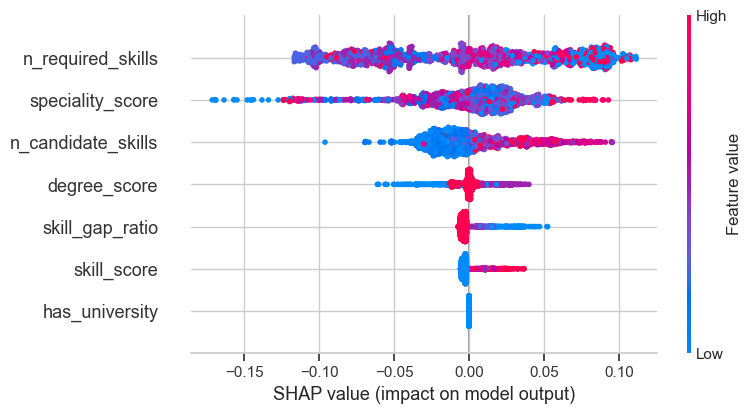


── Example: explain candidate #0 ──


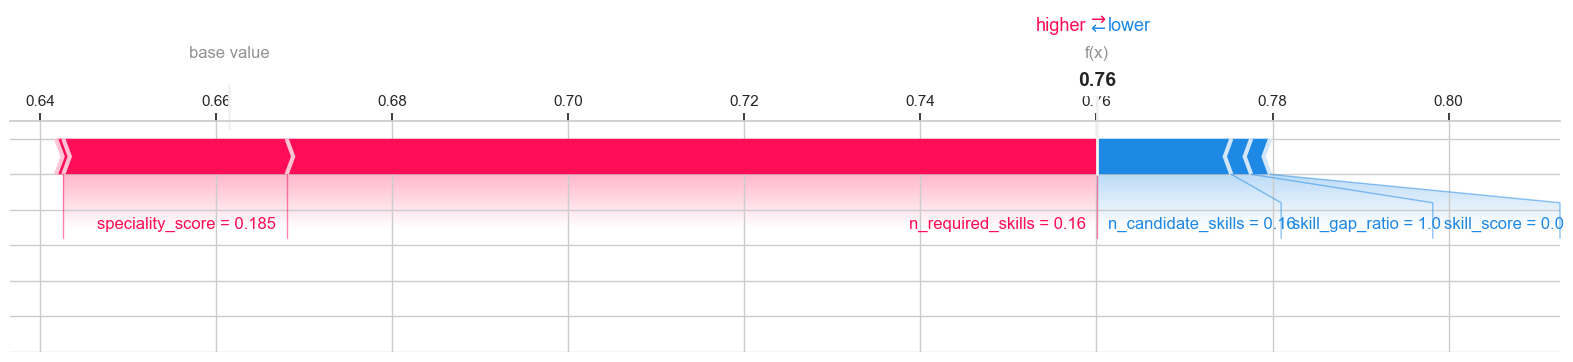

In [18]:
try:
    import shap
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
 
    plt.figure(figsize=(9, 5))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.tight_layout()
    plt.savefig("../models/plots/shap_summary_nb.png", dpi=150, bbox_inches="tight")
    plt.show()
 
    # ── Single candidate explanation ──────────────────────────
    print("\n── Example: explain candidate #0 ──")
    shap.force_plot(
        explainer.expected_value,
        shap_values[0],
        X_test.iloc[0],
        matplotlib=True
    )
except ImportError:
    print("Install SHAP: pip install shap")

# ## 7. Save model

In [19]:
import joblib, json
from pathlib import Path
 
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)
 
joblib.dump(model, MODEL_DIR / "ranking_model.pkl")
 
meta = {
    "mae_test": round(mean_absolute_error(y_test, preds), 4),
    "r2_test":  round(r2_score(y_test, preds), 4),
    "feature_names": list(X.columns),
    "feature_importances": {
        k: round(v, 4)
        for k, v in zip(X.columns, model.feature_importances_)
    }
}
(MODEL_DIR / "model_meta.json").write_text(json.dumps(meta, indent=2))
 
print("Model saved ✓")
print(json.dumps(meta, indent=2))
 

Model saved ✓
{
  "mae_test": 0.1006,
  "r2_test": 0.3855,
  "feature_names": [
    "skill_score",
    "speciality_score",
    "degree_score",
    "has_university",
    "n_candidate_skills",
    "n_required_skills",
    "skill_gap_ratio"
  ],
  "feature_importances": {
    "skill_score": 0.0172,
    "speciality_score": 0.3558,
    "degree_score": 0.0563,
    "has_university": 0.0,
    "n_candidate_skills": 0.177,
    "n_required_skills": 0.372,
    "skill_gap_ratio": 0.0217
  }
}
